In [1]:
# ============================================================
# F1M1 — Módulo 1: EDA Leonali
# Notebook 01 — Carga y exploración inicial
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Cargar dataset
df = pd.read_parquet('../data/processed/Dataset1_anonimizado.parquet')

print(f"✓ Dataset cargado correctamente")
print(f"Shape: {df.shape}")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

✓ Dataset cargado correctamente
Shape: (581306, 15)
Memoria: 111.6 MB


In [2]:
# ============================================================
# PASO 2 — Estructura del dataset
# ============================================================

print("=== TIPOS DE DATOS ===")
print(df.dtypes)

print(f"\n=== VALORES NULOS ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "✓ Sin valores nulos")

print(f"\n=== PRIMERAS 5 FILAS ===")
df.head()

=== TIPOS DE DATOS ===
IdCliente                       str
IdProducto                      str
FechaProceso         datetime64[us]
Producto                        str
Categoria1                      str
Categoria2                      str
marca                           str
Canal1                          str
Canal2                          str
Costo_Entrega               float64
Costo_Produccion            float64
Costo_Venta                 float64
Piezas_Entregadas           float64
Piezas_Ordenadas            float64
Piezas_Producidas           float64
dtype: object

=== VALORES NULOS ===
✓ Sin valores nulos

=== PRIMERAS 5 FILAS ===


,IdCliente,IdProducto,FechaProceso,Producto,Categoria1,Categoria2,marca,Canal1,Canal2,Costo_Entrega,Costo_Produccion,Costo_Venta,Piezas_Entregadas,Piezas_Ordenadas,Piezas_Producidas
0,19e503ba5c1c,PT000013,2017-08-22,Cebolla cuarto de luna 1Kg,Botana,Adicional,Sin Marca,Food Service,Otros,30277.8,30277.8,30277.8,801.0,801.0,801.0
1,19e503ba5c1c,PT000013,2017-08-23,Cebolla cuarto de luna 1Kg,Botana,Adicional,Sin Marca,Food Service,Otros,27216.0,27216.0,30277.8,720.0,801.0,720.0
2,19e503ba5c1c,PT000013,2017-08-25,Cebolla cuarto de luna 1Kg,Botana,Adicional,Sin Marca,Food Service,Otros,21092.4,21092.4,21092.4,558.0,558.0,558.0
3,19e503ba5c1c,PT000013,2017-08-28,Cebolla cuarto de luna 1Kg,Botana,Adicional,Sin Marca,Food Service,Otros,26535.6,26535.6,26535.6,702.0,702.0,702.0
4,19e503ba5c1c,PT000013,2017-08-30,Cebolla cuarto de luna 1Kg,Botana,Adicional,Sin Marca,Food Service,Otros,26535.6,26535.6,26535.6,702.0,702.0,702.0


In [3]:
# ============================================================
# PASO 3 — Estadísticas descriptivas y variables categóricas
# ============================================================

print("=== ESTADÍSTICAS NUMÉRICAS ===")
print(df.describe().round(2))

print("\n=== VARIABLES CATEGÓRICAS ===")
categoricas = ['Categoria1', 'Categoria2', 'marca', 'Canal1', 'Canal2']
for col in categoricas:
    n = df[col].nunique()
    top = df[col].value_counts().index[0]
    pct = df[col].value_counts().iloc[0] / len(df) * 100
    print(f"{col:<12} → {n:>3} únicos | top: '{top}' ({pct:.1f}%)")

print(f"\n=== RANGO TEMPORAL ===")
print(f"Fecha inicio: {df['FechaProceso'].min()}")
print(f"Fecha fin:    {df['FechaProceso'].max()}")
print(f"Período:      {(df['FechaProceso'].max() - df['FechaProceso'].min()).days} días")
print(f"Clientes únicos:  {df['IdCliente'].nunique():,}")
print(f"Productos únicos: {df['IdProducto'].nunique():,}")

=== ESTADÍSTICAS NUMÉRICAS ===
                     FechaProceso  Costo_Entrega  Costo_Produccion  \
count                      581306      581306.00         581306.00   
mean   2018-07-14 18:36:59.132780        5031.31           5128.73   
min           2012-12-31 00:00:00       -5644.38          -1813.48   
25%           2016-04-07 00:00:00         187.60            203.43   
50%           2018-12-07 00:00:00        1133.95           1175.26   
75%           2021-01-19 00:00:00        4552.93           4665.00   
max           2022-11-17 00:00:00      716886.72         716886.72   
std                           NaN       12197.21          12325.67   

       Costo_Venta  Piezas_Entregadas  Piezas_Ordenadas  Piezas_Producidas  
count    581306.00          581306.00         581306.00          581306.00  
mean       5445.72             270.59            292.66             275.93  
min           0.00             -96.00              0.00            -117.00  
25%         248.76            

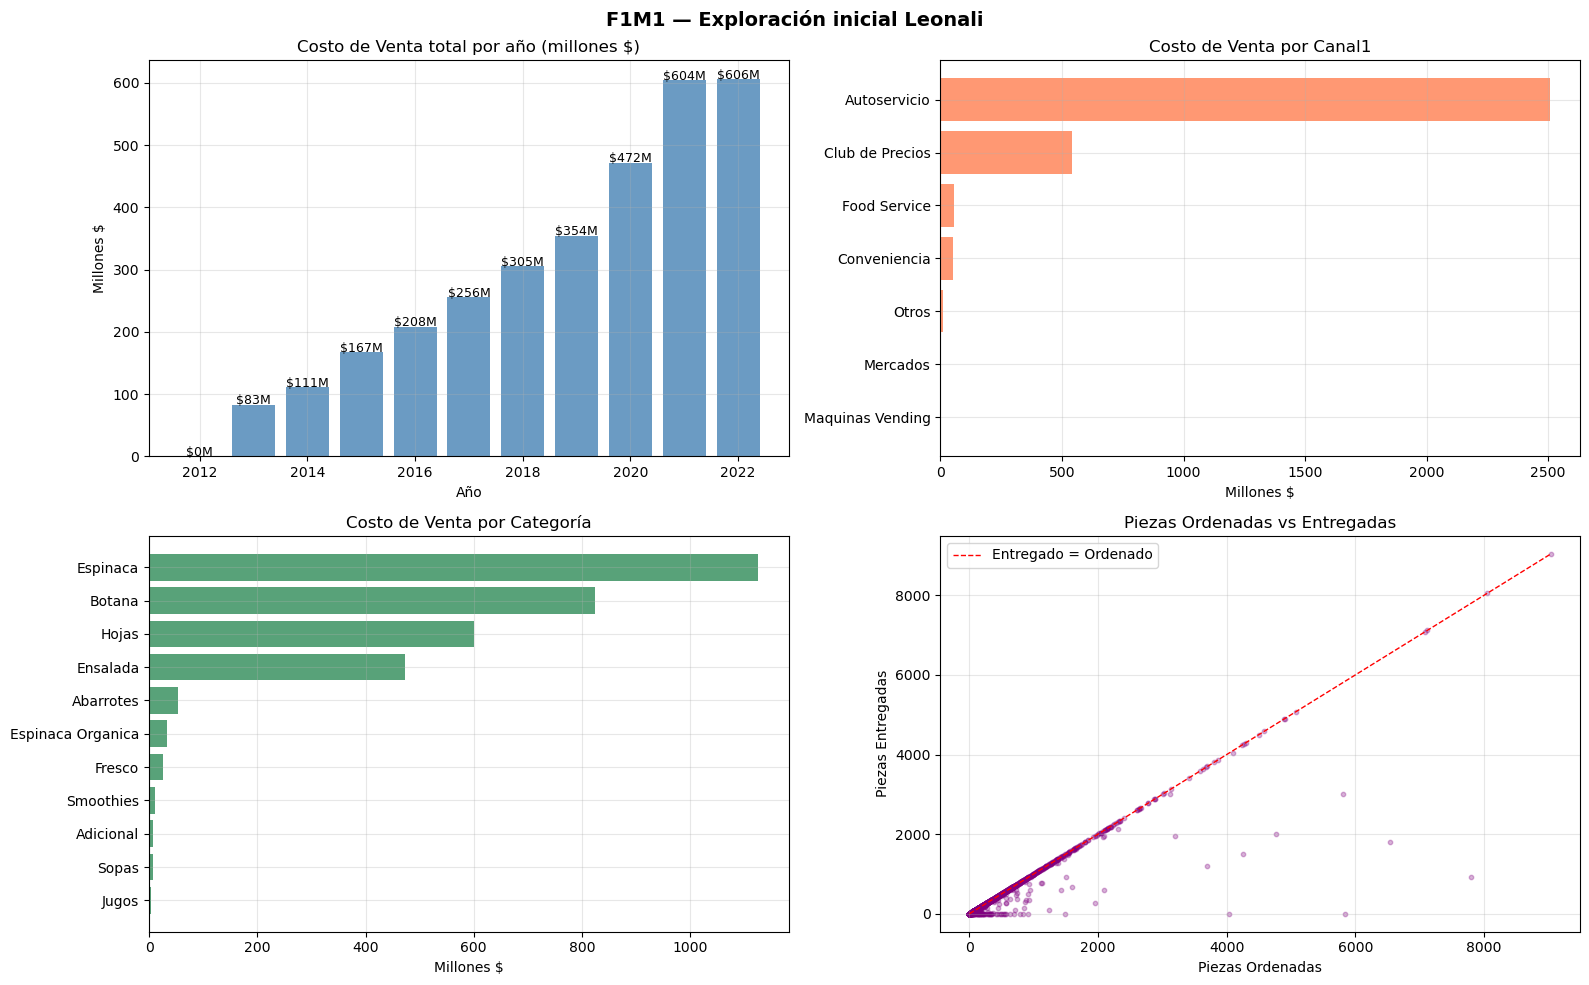

In [5]:
# ============================================================
# PASO 4 — Visualización inicial
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Plot 1: Ventas totales por año ---
df['año'] = df['FechaProceso'].dt.year
ventas_anuales = df.groupby('año')['Costo_Venta'].sum() / 1e6

ax = axes[0,0]
ax.bar(ventas_anuales.index, ventas_anuales.values, color='steelblue', alpha=0.8)
ax.set_title('Costo de Venta total por año (millones $)')
ax.set_xlabel('Año')
ax.set_ylabel('Millones $')
for i, v in enumerate(ventas_anuales.values):
    ax.text(ventas_anuales.index[i], v + 0.5, f'${v:.0f}M', ha='center', fontsize=9)

# --- Plot 2: Distribución por Canal1 ---
ax = axes[0,1]
canal_ventas = df.groupby('Canal1')['Costo_Venta'].sum().sort_values(ascending=True)
ax.barh(canal_ventas.index, canal_ventas.values / 1e6, color='coral', alpha=0.8)
ax.set_title('Costo de Venta por Canal1')
ax.set_xlabel('Millones $')

# --- Plot 3: Distribución por Categoria1 ---
ax = axes[1,0]
cat_ventas = df.groupby('Categoria1')['Costo_Venta'].sum().sort_values(ascending=True)
ax.barh(cat_ventas.index, cat_ventas.values / 1e6, color='seagreen', alpha=0.8)
ax.set_title('Costo de Venta por Categoría')
ax.set_xlabel('Millones $')

# --- Plot 4: Piezas entregadas vs ordenadas (muestra) ---
ax = axes[1,1]
muestra = df.sample(3000, random_state=42)
ax.scatter(muestra['Piezas_Ordenadas'], muestra['Piezas_Entregadas'],
           alpha=0.3, s=10, color='purple')
ax.plot([0, muestra['Piezas_Ordenadas'].max()],
        [0, muestra['Piezas_Ordenadas'].max()],
        'r--', linewidth=1, label='Entregado = Ordenado')
ax.set_title('Piezas Ordenadas vs Entregadas')
ax.set_xlabel('Piezas Ordenadas')
ax.set_ylabel('Piezas Entregadas')
ax.legend()

plt.suptitle('F1M1 — Exploración inicial Leonali', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/01_exploracion_inicial.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ============================================================
# PASO 5 — Verificación de consistencia
# ============================================================

print("=== CLIENTES Y PRODUCTOS ===")
print(f"Clientes únicos:  {df['IdCliente'].nunique():,}")
print(f"Productos únicos: {df['IdProducto'].nunique():,}")
print(f"Combinaciones cliente-producto: {df.groupby(['IdCliente','IdProducto']).ngroups:,}")

print(f"\n=== CONSISTENCIA NOMBRES vs IDs ===")
# ¿Hay productos con mismo nombre pero diferente ID?
prods_por_nombre = df.groupby('Producto')['IdProducto'].nunique()
inconsistentes = prods_por_nombre[prods_por_nombre > 1]
print(f"Productos con múltiples IDs: {len(inconsistentes)}")
if len(inconsistentes) > 0:
    print(inconsistentes.head(10))

# ¿Hay IDs con múltiples nombres?
nombres_por_id = df.groupby('IdProducto')['Producto'].nunique()
inconsistentes2 = nombres_por_id[nombres_por_id > 1]
print(f"\nIDs con múltiples nombres: {len(inconsistentes2)}")
if len(inconsistentes2) > 0:
    print(inconsistentes2.head(10))

print(f"\n=== COBERTURA TEMPORAL POR CLIENTE ===")
cobertura = df.groupby('IdCliente')['FechaProceso'].agg(['min','max'])
cobertura['dias'] = (cobertura['max'] - cobertura['min']).dt.days
print(f"Clientes con datos en todo el período (>3000 días): {(cobertura['dias'] > 3000).sum()}")
print(f"Clientes con menos de 1 año de datos (<365 días):   {(cobertura['dias'] < 365).sum()}")

=== CLIENTES Y PRODUCTOS ===
Clientes únicos:  130
Productos únicos: 233
Combinaciones cliente-producto: 2,464

=== CONSISTENCIA NOMBRES vs IDs ===
Productos con múltiples IDs: 14
Producto
Ens Detox 240gr             2
Ens Verdinna 300gr          2
Espinaca Baby 1Kg           5
Espinaca Baby 250gr         2
Espinaca Baby 500gr         3
Lechuga Italiana 1.5Kg      2
Lechuga Orejona 1.5Kg       2
Mix de Lechugas 1Kg         2
Papa Cambray Saco 4.5 kg    2
Romerito 400gr              2
Name: IdProducto, dtype: int64

IDs con múltiples nombres: 0

=== COBERTURA TEMPORAL POR CLIENTE ===
Clientes con datos en todo el período (>3000 días): 27
Clientes con menos de 1 año de datos (<365 días):   39


In [7]:
# ============================================================
# PASO 6 — Resumen de hallazgos EDA inicial
# ============================================================

print("=" * 60)
print("RESUMEN DE HALLAZGOS — EDA INICIAL LEONALI")
print("=" * 60)

print("""
DATASET:
  • 581,306 registros | 15 columnas | 111 MB
  • Período: dic 2012 – nov 2022 (≈10 años)
  • Granularidad: transacción diaria por cliente-producto

NEGOCIO:
  • Empresa de alimentos frescos/botanas — modelo B2B sell-in
  • 130 clientes únicos históricos (no simultáneos)
  • 233 SKUs únicos por ID — algunos con múltiples IDs
  • Marca dominante: Vegetalistos (88.5% de registros)
  • Canal dominante: Autoservicio (81.5%)

CATEGORÍAS CLAVE:
  • Top por valor: Espinaca > Botana > Hojas > Ensalada
  • Top por volumen: Botana (36% de registros)

CRECIMIENTO:
  • De $83M (2013) a $606M (2022) — crecimiento 8x en 10 años
  • Tendencia consistente sin caídas significativas

ALERTAS DE CALIDAD:
  • 14 productos con múltiples IDs (reformulaciones/errores ERP)
  • Valores negativos en costos y piezas (devoluciones/ajustes)
  • 39 clientes con <1 año de datos (cuentas cortas)
  • Solo 27 clientes con cobertura completa del período
""")

print("PRÓXIMOS PASOS (S5.2):")
print("  • Análisis de tendencias por categoría y canal")
print("  • Estacionalidad mensual")
print("  • Top clientes y productos por valor")


RESUMEN DE HALLAZGOS — EDA INICIAL LEONALI

DATASET:
  • 581,306 registros | 15 columnas | 111 MB
  • Período: dic 2012 – nov 2022 (≈10 años)
  • Granularidad: transacción diaria por cliente-producto

NEGOCIO:
  • Empresa de alimentos frescos/botanas — modelo B2B sell-in
  • 130 clientes únicos históricos (no simultáneos)
  • 233 SKUs únicos por ID — algunos con múltiples IDs
  • Marca dominante: Vegetalistos (88.5% de registros)
  • Canal dominante: Autoservicio (81.5%)

CATEGORÍAS CLAVE:
  • Top por valor: Espinaca > Botana > Hojas > Ensalada
  • Top por volumen: Botana (36% de registros)

CRECIMIENTO:
  • De $83M (2013) a $606M (2022) — crecimiento 8x en 10 años
  • Tendencia consistente sin caídas significativas

ALERTAS DE CALIDAD:
  • 14 productos con múltiples IDs (reformulaciones/errores ERP)
  • Valores negativos en costos y piezas (devoluciones/ajustes)
  • 39 clientes con <1 año de datos (cuentas cortas)
  • Solo 27 clientes con cobertura completa del período

PRÓXIMOS PASOS